In [0]:
# (Removed standalone auth code for Databricks migration)

In [0]:
!pip install mlflow
%pip install --upgrade databricks-feature-store

# In Databricks, authentication is handled automatically!
import mlflow

# Set MLflow to Databricks and point to your experiment
mlflow.set_tracking_uri("databricks")
mlflow.set_experiment("/Users/nsahmad@uchicago.edu/athletes_assignment2")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/2265120110325905', creation_time=1784860179744, effective_trace_archival_retention=None, experiment_id='2265120110325905', last_update_time=1784904939574, lifecycle_stage='active', name='/Users/nsahmad@uchicago.edu/athletes_assignment2', tags={'mlflow.experiment.sourceName': '/Users/nsahmad@uchicago.edu/athletes_assignment2',
 'mlflow.experimentKind': 'custom_model_development',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'nsahmad@uchicago.edu',
 'mlflow.ownerId': '71604044521161'}, trace_location=None, workspace='default'>

In [0]:
with mlflow.start_run(run_name="connection-test"):
    mlflow.log_param("test_param", "hello_databricks")
    mlflow.log_metric("test_metric", 1.0)
    print("MLflow tracking test completed.")

MLflow tracking test completed.


### Dataset Selection and Setup

In [0]:
#EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Update this path to where you uploaded athletes.csv in Databricks
# e.g., Unity Catalog volume: "/Volumes/catalog/schema/volume/athletes.csv"
# or DBFS: "/dbfs/FileStore/tables/athletes.csv"
# Read from Unity Catalog table using Spark, then convert to pandas
athletes_spark = spark.table("workspace.default.athletes")
athletes = athletes_spark.toPandas()

In [0]:
athletes.head(10)

,athlete_id,name,region,team,affiliate,gender,age,height,weight,fran,helen,grace,filthy50,fgonebad,run400,run5k,candj,snatch,deadlift,backsq,pullups,eat,train,background,experience,schedule,howlong
0,2554.0,Pj Ablang,South West,Double Edge,Double Edge CrossFit,Male,24.0,70.0,166.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220.0,NaN,400.0,305.0,NaN,None,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|I r...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
1,3517.0,Derek Abdella,None,None,None,Male,42.0,70.0,190.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,I have a coach who determines my programming|I...,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
2,4691.0,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None
3,5164.0,Abo Brandon,Southern California,LAX CrossFit,LAX CrossFit,Male,40.0,67.0,NaN,211.0,645.0,300.0,NaN,196.0,NaN,NaN,245.0,200.0,375.0,325.0,25.0,I eat 1-3 full cheat meals per week|,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|,4+ years|
4,5286.0,Bryce Abbey,None,None,None,Male,32.0,65.0,149.0,206.0,465.0,NaN,1053.0,NaN,NaN,1081.0,205.0,150.0,NaN,325.0,50.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I inc...,I played college sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I strictly s...,1-2 years|
5,6491.0,Jason Abney,None,None,None,Male,37.0,73.0,230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,265.0,200.0,435.0,414.0,NaN,I eat strict Paleo|,I workout mostly at a CrossFit Affiliate|I rec...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I typically ...,4+ years|
6,6610.0,Anthony Abeel,South Central,Get Lifted,Get Lifted CrossFit,Male,21.0,72.0,175.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,I eat quality foods but don't measure the amou...,I workout mostly at a CrossFit Affiliate|I hav...,I have no athletic background besides CrossFit|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 3+ times a wee...,2-4 years|
7,7268.0,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None
8,7463.0,Tye Abell,None,None,None,Male,30.0,72.0,175.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None
9,8242.0,Ryan Achilles,None,None,None,Male,40.0,68.0,177.0,205.0,614.0,NaN,1647.0,332.0,NaN,1361.0,225.0,185.0,365.0,365.0,NaN,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I rec...,I played youth or high school level sports|I p...,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I typically ...,2-4 years|


In [0]:
def count_distinct_values(df, include_nulls=False):

    results = []

    for column in df.columns:
        distinct_count = df[column].nunique(dropna=not include_nulls)
        total_count = len(df)
        null_count = df[column].isnull().sum()

        results.append({
            'Column': column,
            'Data_Type': df[column].dtype,
            'Distinct_Count': distinct_count,
            'Total_Rows': total_count,
            'Null_Count': null_count,
            'Pct_Unique': round(distinct_count / total_count * 100, 2)
        })

    return pd.DataFrame(results).sort_values('Distinct_Count', ascending=False)

In [0]:
ath_dist = count_distinct_values(athletes, include_nulls=True)
ath_dist

,Column,Data_Type,Distinct_Count,Total_Rows,Null_Count,Pct_Unique
0,athlete_id,float64,423004,423006,3,100.00
1,name,object,306753,423006,91896,72.52
4,affiliate,object,9779,423006,181090,2.31
3,team,object,4533,423006,267846,1.07
12,filthy50,float64,2070,423006,403647,0.49
15,run5k,float64,1780,423006,386909,0.42
10,helen,float64,1065,423006,392727,0.25
9,fran,float64,1042,423006,367580,0.25
11,grace,float64,875,423006,382261,0.21
18,deadlift,float64,630,423006,307683,0.15


In [0]:
#remove completely nulls from athletes
no_null_athletes = athletes.dropna(axis=1, how='all')


In [0]:
#gender pct
gender_pct = no_null_athletes['gender'].value_counts(normalize=True) * 100
gender_pct

gender
Male      58.870466
Female    41.112621
--         0.016913
Name: proportion, dtype: float64

In [0]:
#remove missing gender
no_null_athletes = no_null_athletes.dropna(subset=['gender'])

In [0]:
#what are the unique string entries
for column in no_null_athletes.columns:
    unique_values = no_null_athletes[column].unique()
    print(f"Unique values in column '{column}':")
    print(unique_values)

Unique values in column 'athlete_id':
[  2554.   3517.   5164. ... 608828. 628881. 631847.]
Unique values in column 'name':
['Pj Ablang' 'Derek Abdella' 'Abo Brandon' ... 'Marisol Smith'
 'Pedrini Morgane' 'Eden Kenny']
Unique values in column 'region':
['South West' None 'Southern California' 'South Central' 'Central East'
 'Europe' 'North East' 'Africa' 'South East' 'Australia'
 'Northern California' 'Latin America' 'Canada East' 'North Central'
 'North West' 'Mid Atlantic' 'Canada West' 'Asia']
Unique values in column 'team':
['Double Edge' None 'LAX CrossFit' ... 'CrossFit AC' 'BLACK SHEEP'
 'CrossFit DV8']
Unique values in column 'affiliate':
['Double Edge CrossFit' None 'LAX CrossFit' ... 'Black and Gold CrossFit'
 'Reebok CrossFit Gurgaon' 'CrossFit Shardana']
Unique values in column 'gender':
['Male' 'Female' '--']
Unique values in column 'age':
[ 24.  42.  40.  32.  37.  21.  30.  31.  43.  23.  27.  28.  39.  35.
  26.  47.  38.  36.  44.  29.  34.  22.  46.  25.  41.  33.  4

In [0]:
#print one entry for experience column
print(no_null_athletes['experience'].head(5))


0    I began CrossFit with a coach (e.g. at an affi...
1    I began CrossFit with a coach (e.g. at an affi...
3    I began CrossFit by trying it alone (without a...
4    I began CrossFit by trying it alone (without a...
5    I began CrossFit by trying it alone (without a...
Name: experience, dtype: object


In [0]:
cols_to_clean = ['height', 'weight', 'grace', 'fgonebad', 'run400', 'candj', 'snatch', 'deadlift', 'backsq', 'pullups']

# Force these columns to numeric, coercing any errors into NaN
for col in cols_to_clean:
    no_null_athletes[col] = pd.to_numeric(no_null_athletes[col], errors='coerce')

# Display the data types and non-null counts to verify
no_null_athletes[cols_to_clean].info()

<class 'pandas.core.frame.DataFrame'>
Index: 331110 entries, 0 to 423005
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   height    159869 non-null  float64
 1   weight    229890 non-null  float64
 2   grace     40745 non-null   float64
 3   fgonebad  29738 non-null   float64
 4   run400    22246 non-null   float64
 5   candj     104435 non-null  float64
 6   snatch    97280 non-null   float64
 7   deadlift  115323 non-null  float64
 8   backsq    110517 non-null  float64
 9   pullups   50608 non-null   float64
dtypes: float64(10)
memory usage: 27.8 MB


In [0]:
# Check summary statistics to identify extreme outliers in basic physical attributes
print("Summary statistics for Age, Height, and Weight:")
display(no_null_athletes[['age', 'height', 'weight']].describe())

# Let's count how many rows fall outside of realistic human ranges
# Assuming Age: 13-80, Height: 48-90 inches, Weight: 80-400 lbs
unrealistic_data = no_null_athletes[
    (no_null_athletes['age'] > 80) | (no_null_athletes['age'] < 13) |
    (no_null_athletes['height'] > 90) | (no_null_athletes['height'] < 48) |
    (no_null_athletes['weight'] > 400) | (no_null_athletes['weight'] < 80)
]

print(f"\nFound {len(unrealistic_data)} athletes with unrealistic age, height, or weight values.")
display(unrealistic_data[['age', 'height', 'weight']].head())

Summary statistics for Age, Height, and Weight:


age,height,weight
331110.0,159869.0,229890.0
32.516749720636646,120.6216840037781,170.8961372830484
7.730671132570801,20979.94855160401,58.37979934195937
13.0,0.0,1.0
27.0,66.0,145.0
31.0,69.0,170.0
37.0,72.0,192.0
125.0,8388607.0,20175.0



Found 2552 athletes with unrealistic age, height, or weight values.


age,height,weight
30.0,71.0,79.0
33.0,68.0,67.0
29.0,71.0,79.0
33.0,null,70.0
26.0,69.0,67.0


In [0]:
#check for negative values among all numeric columns
numeric_cols = no_null_athletes.select_dtypes(include='number')
negative_counts = (numeric_cols < 0).sum()
print("Number of negative values in each numeric column:")
print(negative_counts)


Number of negative values in each numeric column:
athlete_id     0
age            0
height         0
weight         0
fran           0
helen          0
grace          1
filthy50       0
fgonebad       0
run400         0
run5k          0
candj          1
snatch         0
deadlift       4
backsq         1
pullups       17
dtype: int64


In [0]:
import numpy as np

# Get all numeric columns
numeric_cols = no_null_athletes.select_dtypes(include='number').columns

# Replace negative values with NaN
for col in numeric_cols:
    no_null_athletes.loc[no_null_athletes[col] < 0, col] = np.nan

# Verify the changes
remaining_negatives = (no_null_athletes.select_dtypes(include='number') < 0).sum().sum()
print(f"Total negative values remaining in the dataset: {remaining_negatives}")


Total negative values remaining in the dataset: 0


In [0]:
import numpy as np

# Replace outliers with NaN
no_null_athletes.loc[(no_null_athletes['age'] > 80) | (no_null_athletes['age'] < 13), 'age'] = np.nan
no_null_athletes.loc[(no_null_athletes['height'] > 90) | (no_null_athletes['height'] < 48), 'height'] = np.nan
no_null_athletes.loc[(no_null_athletes['weight'] > 400) | (no_null_athletes['weight'] < 80), 'weight'] = np.nan

# Verify changes
print("Summary statistics after replacing outliers with NaN:")
display(no_null_athletes[['age', 'height', 'weight']].describe())


Summary statistics after replacing outliers with NaN:


age,height,weight
331102.0,158175.0,228986.0
32.5146420136393,68.56289552710605,171.06009974408917
7.718743036909529,3.9990626579552497,33.50203674342339
13.0,48.0,80.0
27.0,66.0,145.0
31.0,69.0,171.0
37.0,72.0,192.0
62.0,89.0,400.0


In [0]:
# List of multi-select survey columns to split
multi_select_cols = ['experience', 'schedule', 'background', 'eat', 'train']

# Create dummy variables for each column
for col in multi_select_cols:
    if col in no_null_athletes.columns:
        # Split by the pipe character and create dummy variables
        dummies = no_null_athletes[col].str.get_dummies(sep='|')

        # Add a prefix so we know which original column these came from
        dummies = dummies.add_prefix(f"{col}_")

        # Concatenate the new columns to the dataframe
        no_null_athletes = pd.concat([no_null_athletes, dummies], axis=1)

        # Drop the original text column
        no_null_athletes = no_null_athletes.drop(col, axis=1)

# Display the changes
print(f"Total columns after dummy creation: {len(no_null_athletes.columns)}")
display(no_null_athletes.head())


Total columns after dummy creation: 56


athlete_id,name,region,team,affiliate,gender,age,height,weight,fran,helen,grace,filthy50,fgonebad,run400,run5k,candj,snatch,deadlift,backsq,pullups,howlong,experience_Decline to answer,experience_I began CrossFit by trying it alone (without a coach),experience_I began CrossFit with a coach (e.g. at an affiliate),experience_I have attended one or more specialty courses,experience_I have completed the CrossFit Level 1 certificate course,experience_I have had a life changing experience due to CrossFit,experience_I train other people,schedule_Decline to answer,schedule_I do multiple workouts in a day 1x a week,schedule_I do multiple workouts in a day 2x a week,schedule_I do multiple workouts in a day 3+ times a week,schedule_I strictly schedule my rest days,schedule_I typically rest 4 or more days per month,schedule_I typically rest fewer than 4 days per month,schedule_I usually only do 1 workout a day,background_Decline to answer,background_I have no athletic background besides CrossFit,background_I played college sports,background_I played professional sports,background_I played youth or high school level sports,background_I regularly play recreational sports,eat_Decline to answer,eat_I eat 1-3 full cheat meals per week,eat_I eat quality foods but don't measure the amount,eat_I eat strict Paleo,eat_I eat whatever is convenient,eat_I weigh and measure my food,train_Decline to answer,train_I have a coach who determines my programming,train_I incorporate CrossFit.com workouts,train_I record my workouts,train_I workout mostly at a CrossFit Affiliate,"train_I workout mostly at home, work, or a traditional gym",train_I write my own programming
2554.0,Pj Ablang,South West,Double Edge,Double Edge CrossFit,Male,24.0,70.0,166.0,null,null,null,null,null,null,null,220.0,null,400.0,305.0,null,4+ years|,0,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,1,1,0,0
3517.0,Derek Abdella,null,null,null,Male,42.0,70.0,190.0,null,null,null,null,0.0,null,null,null,null,null,null,null,4+ years|,0,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0
5164.0,Abo Brandon,Southern California,LAX CrossFit,LAX CrossFit,Male,40.0,67.0,null,211.0,645.0,300.0,null,196.0,null,null,245.0,200.0,375.0,325.0,25.0,4+ years|,0,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,1,0,0
5286.0,Bryce Abbey,null,null,null,Male,32.0,65.0,149.0,206.0,465.0,null,1053.0,null,null,1081.0,205.0,150.0,null,325.0,50.0,1-2 years|,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,1,1,0,1
6491.0,Jason Abney,null,null,null,Male,37.0,73.0,230.0,null,null,null,null,null,null,null,265.0,200.0,435.0,414.0,null,4+ years|,0,1,0,0,1,1,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0


--- Deadlift Summary (Before Cleaning) ---


count    1.153190e+05
mean     6.970790e+02
std      5.523331e+04
min      0.000000e+00
25%      2.550000e+02
50%      3.450000e+02
75%      4.150000e+02
max      8.388607e+06
Name: deadlift, dtype: float64


Found 3854 athletes with unrealistic deadlift weights.

--- Deadlift Summary (After Cleaning) ---


count    111465.000000
mean        343.917266
std          99.467747
min          50.000000
25%         265.000000
50%         350.000000
75%         415.000000
max        1168.000000
Name: deadlift, dtype: float64

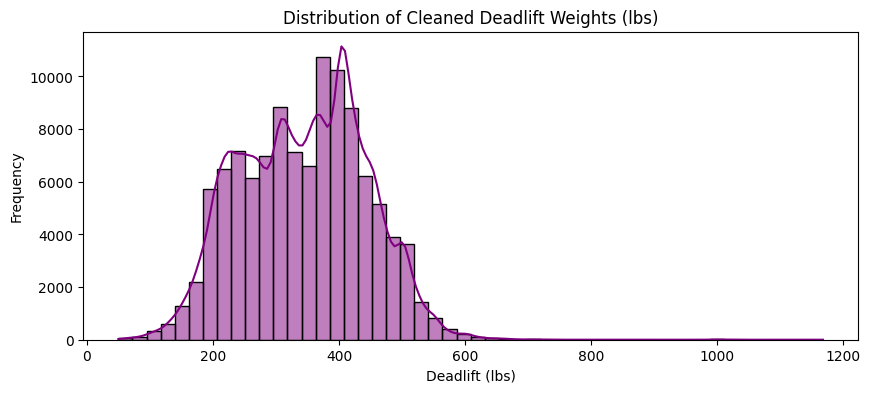

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Deadlift Summary (Before Cleaning) ---")
display(no_null_athletes['deadlift'].describe())

# Count extreme values (under 50 lbs or over 1200 lbs)
extreme_deadlifts = no_null_athletes[(no_null_athletes['deadlift'] < 50) | (no_null_athletes['deadlift'] > 1200)]
print(f"\nFound {len(extreme_deadlifts)} athletes with unrealistic deadlift weights.")

# Replace extreme outliers with NaN
no_null_athletes.loc[(no_null_athletes['deadlift'] < 50) | (no_null_athletes['deadlift'] > 1200), 'deadlift'] = np.nan

print("\n--- Deadlift Summary (After Cleaning) ---")
display(no_null_athletes['deadlift'].describe())

# Visualize the cleaned distribution
plt.figure(figsize=(10, 4))
sns.histplot(no_null_athletes['deadlift'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Cleaned Deadlift Weights (lbs)')
plt.xlabel('Deadlift (lbs)')
plt.ylabel('Frequency')
plt.show()

2. MLOps Platform Selection and Configuration

I chose MLFlow because I want to utilize a tool that is the industry standard in managing the life cycle of Machine Learning artifacts.

In [0]:
#MLFLOW

#3. End-to-end ML Pipeline

### Retrain the Machine Learning Pipeline
Now that the target variable is cleaned of extreme outliers, let's retrain our `RandomForestRegressor` and re-evaluate its performance.

In [0]:
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Data Ingestion
# We will use the already partially cleaned dataset 'no_null_athletes'
df = no_null_athletes.copy()

# 2 & 3. Feature Engineering / Preprocessing Prep
# Feature Creation: Calculate BMI from weight (lbs) and height (inches)
df['BMI'] = (df['weight'] / (df['height'] ** 2)) * 703

# Drop rows where our target variable is missing so we can train properly
target = 'deadlift'
df = df.dropna(subset=[target])

# Select our features for the model
num_features = ['age', 'height', 'weight', 'BMI']
cat_features = ['gender', 'region']
# Include a few of the dummy variables we created earlier
dummy_features = [col for col in df.columns if 'experience_' in col or 'schedule_' in col][:5]

features = num_features + cat_features + dummy_features
X = df[features]
y = df[target]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Data Preprocessing (Scikit-Learn Transformers)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features + dummy_features),
    ('cat', cat_transformer, cat_features)
])

# 4. Model Training Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42))
])

# MLflow Tracking integration
with mlflow.start_run(run_name="deadlift_prediction_pipeline"):
    print("Training model...")
    model.fit(X_train, y_train)

    # 5. Model Evaluation
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\n--- Model Evaluation Metrics ---")
    print(f"MAE:  {mae:.2f} lbs")
    print(f"RMSE: {rmse:.2f} lbs")
    print(f"R2:   {r2:.4f}")

    # Log parameters and metrics to MLflow
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 50)
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)

    # Log the entire pipeline model
    mlflow.sklearn.log_model(
        model,
        "model",
        skops_trusted_types=["numpy.dtype", "sklearn.compose._column_transformer._RemainderColsList"]
    )
    print("\nPipeline execution complete. Model and metrics successfully logged to MLflow.")

Training model...

--- Model Evaluation Metrics ---
MAE:  45.18 lbs
RMSE: 60.10 lbs
R2:   0.6357


2026/07/24 15:05:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-ea811a49-a4a8.cloud.databricks.com/ml/experiments/2265120110325905/models/m-641b9de89a6243af81b86aea92223686?o=7474650194682147
2026/07/24 15:05:19 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.



Pipeline execution complete. Model and metrics successfully logged to MLflow.


#4. Feature Store Integration

In [0]:
%pip install databricks-feature-store


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from databricks.feature_store import FeatureStoreClient

# 1. Initialize the Feature Store client
fs = FeatureStoreClient()

# 2. Spark/Parquet/Delta does not allow spaces or special characters in column names.
# Let's clean up our dummy variable names before converting.
# Delta disallows: space, comma, semicolon, {, }, (, ), \n, \t, =
import re
df_fs = df.copy()
# Replace all non-alphanumeric characters (except underscore) with underscore
# Then remove any leading/trailing underscores and collapse multiple underscores

df_fs.columns = [c.replace(' ', '_').replace('+', '_plus').replace('(', '').replace(')', '').replace(',', '').replace('.', '') for c in df_fs.columns]



# 3. Convert our cleaned pandas DataFrame to a PySpark DataFrame
spark_df = spark.createDataFrame(df_fs)

# 4. Create the feature table in Databricks
# Change to catalog.schema.table_name if using Unity Catalog (e.g. "main.default.athletes_features")
table_name = "athletes_features_v2" 

fs.create_table(
    name=table_name,
    primary_keys=["athlete_id"],
    df=spark_df,
    description="Cleaned CrossFit athletes data with engineered BMI and dummy variables."
)

print(f"Successfully registered {table_name} in the Databricks Feature Store!")

Successfully registered athletes_features_v2 in the Databricks Feature Store!


Demonstration of feature retrieval, utilization, and Batch inference

In [0]:
from databricks.feature_store import FeatureLookup

# ---------------------------------------------------------
# 1. RETRIEVAL (Training)
# ---------------------------------------------------------
# Imagine you only have a table of athlete_ids and their target variable (labels)
training_labels = spark_df.select("athlete_id", "deadlift")

# Get all column names except the ID and our label to avoid collisions/leakage
feature_cols = [c for c in spark_df.columns if c not in ["athlete_id", "deadlift"]]

# We tell Databricks: "Look up these specific features in the athletes_features table using athlete_id"
model_feature_lookups = [
    FeatureLookup(
        table_name=table_name,
        lookup_key="athlete_id",
        feature_names=feature_cols # <--- EXPLICITLY specify features to avoid pulling the label
    )
]

# Create the training dataset
# Databricks automatically joins our labels with the feature store data
training_set = fs.create_training_set(
    df=training_labels,
    feature_lookups=model_feature_lookups,
    label="deadlift",
    exclude_columns=["athlete_id"] # Don't pass the ID to the ML model
)

# Load into a pandas DataFrame for scikit-learn training
training_pd = training_set.load_df().toPandas()
print("Training data retrieved from Feature Store:")
display(training_pd.head(3))

Training data retrieved from Feature Store:


name,region,team,affiliate,gender,age,height,weight,fran,helen,grace,filthy50,fgonebad,run400,run5k,candj,snatch,backsq,pullups,howlong,experience_Decline_to_answer,experience_I_began_CrossFit_by_trying_it_alone_without_a_coach,experience_I_began_CrossFit_with_a_coach_eg_at_an_affiliate,experience_I_have_attended_one_or_more_specialty_courses,experience_I_have_completed_the_CrossFit_Level_1_certificate_course,experience_I_have_had_a_life_changing_experience_due_to_CrossFit,experience_I_train_other_people,schedule_Decline_to_answer,schedule_I_do_multiple_workouts_in_a_day_1x_a_week,schedule_I_do_multiple_workouts_in_a_day_2x_a_week,schedule_I_do_multiple_workouts_in_a_day_3_plus_times_a_week,schedule_I_strictly_schedule_my_rest_days,schedule_I_typically_rest_4_or_more_days_per_month,schedule_I_typically_rest_fewer_than_4_days_per_month,schedule_I_usually_only_do_1_workout_a_day,background_Decline_to_answer,background_I_have_no_athletic_background_besides_CrossFit,background_I_played_college_sports,background_I_played_professional_sports,background_I_played_youth_or_high_school_level_sports,background_I_regularly_play_recreational_sports,eat_Decline_to_answer,eat_I_eat_1-3_full_cheat_meals_per_week,eat_I_eat_quality_foods_but_don't_measure_the_amount,eat_I_eat_strict_Paleo,eat_I_eat_whatever_is_convenient,eat_I_weigh_and_measure_my_food,train_Decline_to_answer,train_I_have_a_coach_who_determines_my_programming,train_I_incorporate_CrossFitcom_workouts,train_I_record_my_workouts,train_I_workout_mostly_at_a_CrossFit_Affiliate,train_I_workout_mostly_at_home_work_or_a_traditional_gym,train_I_write_my_own_programming,BMI,deadlift
Mark Laverty,Europe,Where the elite are forged,CrossFit 8020,Male,32.0,68.0,160.0,null,null,null,null,null,null,null,176.0,121.0,287.0,null,2-4 years|,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,24.325259515570938,353.0
Steve Hermonat,South Central,CrossFit Ammo,CrossFit Ammo,Male,49.0,69.0,160.0,null,null,null,null,null,null,1572.0,null,115.0,215.0,10.0,1-2 years|,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,1,1,0,0,23.625288804872927,275.0
Jerod Bulk,Canada West,Kamloops CrossFit,Kamloops CrossFit,Male,37.0,null,240.0,null,null,null,2040.0,null,null,null,185.0,125.0,225.0,25.0,null,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,355.0


In [0]:
# ---------------------------------------------------------
# 2. UTILIZATION (Logging the Model with Lineage)
# ---------------------------------------------------------
# Let's train a simple model for demonstration on just numeric features to avoid pipeline complexities
X_train_fs = training_pd[['age', 'height', 'weight', 'BMI']].fillna(0)
y_train_fs = training_pd['deadlift'].fillna(0)

from sklearn.ensemble import RandomForestRegressor
demo_model = RandomForestRegressor(n_estimators=10, max_depth=5)
demo_model.fit(X_train_fs, y_train_fs)

# We use fs.log_model instead of mlflow.sklearn.log_model
# This "packages" the feature lookup logic directly inside the MLflow model!
with mlflow.start_run(run_name="feature_store_demo"):
    fs.log_model(
        model=demo_model,
        artifact_path="model_with_features",
        flavor=mlflow.sklearn,
        training_set=training_set,       # <--- Crucial: ties model to feature table
        registered_model_name="athletes_fs_model" # Registers it to Unity Catalog / Workspace Registry
    )

print("Model logged! The model now internally knows it requires 'athlete_id' to look up features.")

🔗 View Logged Model at: https://dbc-ea811a49-a4a8.cloud.databricks.com/ml/experiments/2265120110325905/models/m-370517143c214c6590d5e5de1b822d54?o=7474650194682147
/local_disk0/.ephemeral_nfs/envs/pythonEnv-68be43fd-db13-418b-8e2e-cfa7ac0ccdb5/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3341: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(
Registered model 'athletes_fs_model' already exists. Creating a new version of this model...
2026/07/24 15:05:57 WARNING mlflow.tracking._model_registry.fluent: Run with id 15203a54bdf444a1b9c34d1f977e6dc3 has no artifacts at artifact path 'model_with_features', registering model based on models:/m-370517143c214c6590d5e5de1b822d54 instead


Uploading artifacts:   0%|          | 0/15 [00:00<?, ?it/s]

🔗 Created version '3' of model 'workspace.default.athletes_fs_model': https://dbc-ea811a49-a4a8.cloud.databricks.com/explore/data/models/workspace/default/athletes_fs_model/version/3?o=7474650194682147


Model logged! The model now internally knows it requires 'athlete_id' to look up features.


In [0]:
# ---------------------------------------------------------
# 3. UTILIZATION (Batch Inference)
# ---------------------------------------------------------
# Imagine new data arriving tomorrow. 
# We ONLY know their athlete_ids, we don't need to rebuild their features!
inference_data = spark.createDataFrame([
    (2554.0,),
    (5164.0,)
], schema=["athlete_id"])

print("Input data for scoring (Notice: NO features provided, only ID):")
display(inference_data.toPandas())

# Score the batch.
# Databricks intercepts this, queries the feature store for age/height/weight/BMI,
# joins it, and runs the prediction automatically.
predictions = fs.score_batch(
    "models:/athletes_fs_model/1", 
    inference_data
)

print("\nPredictions with automatically joined features:")
display(predictions.toPandas())

Input data for scoring (Notice: NO features provided, only ID):


athlete_id
2554.0
5164.0


---------------------------------------------------------------------------
InvalidVersion                            Traceback (most recent call last)
File <command-6545300694218714>, line 17
     12 display(inference_data.toPandas())
     14 # Score the batch.
     15 # Databricks intercepts this, queries the feature store for age/height/weight/BMI,
     16 # joins it, and runs the prediction automatically.
---> 17 predictions = fs.score_batch(
     18     "models:/athletes_fs_model/1", 
     19     inference_data
     20 )
     22 print("\nPredictions with automatically joined features:")
     23 display(predictions.toPandas())

File /local_disk0/.ephemeral_nfs/envs/pythonEnv-68be43fd-db13-418b-8e2e-cfa7ac0ccdb5/lib/python3.12/site-packages/databricks/feature_store/client.py:968, in FeatureStoreClient.score_batch(self, model_uri, df, result_type)
    861 def score_batch(
    862     self, model_uri: str, df: DataFrame, result_type: str = "double"
    863 ) -> DataFrame:
    864     

#5. Feature Versioning


Explanation of Feature Versions:

Version 1 (athletes_features_v1): Represents the baseline dataset. It contains only raw numeric physical attributes (age, height, weight) without any transformations, cleaning dummy variables, or engineered metrics.
Version 2 (athletes_features_v2): Represents the enhanced dataset. In addition to the base attributes, it includes engineered features like BMI and flattened dummy variables for survey responses (which we built and stored previously).
Let's build and store v1 in the Feature Store to complement the v2 we already registered.

In [0]:
# Define Version 1 features (Base features only, no BMI or dummies)
v1_cols = ['athlete_id', 'age', 'height', 'weight']

# Filter to valid rows and create Spark DataFrame
df_v1 = df_fs[v1_cols].dropna()
spark_df_v1 = spark.createDataFrame(df_v1)

table_name_v1 = "athletes_features_v1"

# Create the Version 1 table in the Feature Store
try:
    fs.create_table(
        name=table_name_v1,
        primary_keys=["athlete_id"],
        df=spark_df_v1,
        description="Version 1: Base athlete physical attributes (age, height, weight) without engineered features."
    )
    print(f"Successfully registered {table_name_v1} in the Databricks Feature Store!")
except Exception as e:
    print(f"Table might already exist or encountered an error: {e}")

2026/07/24 15:10:46 INFO databricks.ml_features._compute_client._compute_client: Setting columns ['athlete_id'] of table 'workspace.default.athletes_features_v1' to NOT NULL.
2026/07/24 15:10:48 INFO databricks.ml_features._compute_client._compute_client: Setting Primary Keys constraint ['athlete_id'] on table 'workspace.default.athletes_features_v1'.
2026/07/24 15:10:55 INFO databricks.ml_features._compute_client._compute_client: Created feature table 'workspace.default.athletes_features_v1'.


Successfully registered athletes_features_v1 in the Databricks Feature Store!


#6 Experimentation and Model Training (20 Points)


We will now run 4 experiments using the same algorithm (RandomForestRegressor), mixing 2 feature versions and 2 hyperparameter configurations. Everything will be logged to MLflow, establishing lineage back to the Databricks Feature Store.

In [0]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Define the Two Hyperparameter Configurations
hyperparam_configs = [
    {"n_estimators": 50, "max_depth": 5},   # Config A: Faster, less prone to overfitting
    {"n_estimators": 100, "max_depth": 10}  # Config B: Deeper, potentially more accurate
]

# 2. Define the Two Feature Versions (Using our Feature Store tables)
feature_versions = [
    {
        "version_name": "v1_base", 
        "table": table_name_v1, 
        "features": ["age", "height", "weight"]
    },
    {
        "version_name": "v2_engineered", 
        "table": table_name, # This is 'athletes_features_v2' from earlier
        "features": ["age", "height", "weight", "BMI"] # Including engineered BMI for comparison
    }
]

# Create a DataFrame containing just the IDs and the Label (Target)
# We'll drop NaNs on the target variable to ensure clean training
labels_df = spark.createDataFrame(df_fs[['athlete_id', 'deadlift']].dropna())

print("Starting Experimentation...")
print("=" * 40)

# 3. Run Experiments
for fv in feature_versions:
    # A. Retrieve Data via Feature Store
    lookups = [
        FeatureLookup(
            table_name=fv["table"], 
            lookup_key="athlete_id", 
            feature_names=fv["features"]
        )
    ]
    
    # Databricks dynamically joins the labels with the requested features
    training_set = fs.create_training_set(
        df=labels_df, 
        feature_lookups=lookups, 
        label="deadlift", 
        exclude_columns=["athlete_id"]
    )
    
    # B. Prepare for Scikit-Learn
    train_pd = training_set.load_df().toPandas()
    # Drop any rows where features couldn't be joined or contain nulls
    train_pd = train_pd.dropna()
    
    X = train_pd[fv["features"]]
    y = train_pd["deadlift"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # C. Loop Through Hyperparameter Configurations
    for config in hyperparam_configs:
        run_name = f"RF_{fv['version_name']}_est{config['n_estimators']}_depth{config['max_depth']}"
        
        with mlflow.start_run(run_name=run_name):
            # Train
            model = RandomForestRegressor(**config, random_state=42)
            model.fit(X_train, y_train)
            
            # Evaluate
            preds = model.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            r2 = r2_score(y_test, preds)
            
            # Log Parameters & Metrics to MLflow
            mlflow.log_param("feature_version", fv["version_name"])
            mlflow.log_params(config)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("r2", r2)
            
            # Log Model with Feature Store Lineage
            fs.log_model(
                model=model,
                artifact_path="model",
                flavor=mlflow.sklearn,
                training_set=training_set,
                skops_trusted_types=["numpy.dtype", "sklearn.compose._column_transformer._RemainderColsList"]
            )
            
            print(f"Completed Run: {run_name}")
            print(f"  -> RMSE: {rmse:.2f} | R2: {r2:.4f}\n")
            
print("All experiments successfully logged to MLflow!")

Starting Experimentation...


🔗 View Logged Model at: https://dbc-ea811a49-a4a8.cloud.databricks.com/ml/experiments/2265120110325905/models/m-1877d91fbe034807a5ffec38dc7e420c?o=7474650194682147
/local_disk0/.ephemeral_nfs/envs/pythonEnv-68be43fd-db13-418b-8e2e-cfa7ac0ccdb5/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3341: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(


Completed Run: RF_v1_base_est50_depth5
  -> RMSE: 68.51 | R2: 0.5145



🔗 View Logged Model at: https://dbc-ea811a49-a4a8.cloud.databricks.com/ml/experiments/2265120110325905/models/m-3341a122a661461cbe98e3a4a9a1fb16?o=7474650194682147
/local_disk0/.ephemeral_nfs/envs/pythonEnv-68be43fd-db13-418b-8e2e-cfa7ac0ccdb5/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3341: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(


Completed Run: RF_v1_base_est100_depth10
  -> RMSE: 67.56 | R2: 0.5279



🔗 View Logged Model at: https://dbc-ea811a49-a4a8.cloud.databricks.com/ml/experiments/2265120110325905/models/m-ff2eed9cb0394f768c1fe5675083fd9c?o=7474650194682147
/local_disk0/.ephemeral_nfs/envs/pythonEnv-68be43fd-db13-418b-8e2e-cfa7ac0ccdb5/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3341: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(


Completed Run: RF_v2_engineered_est50_depth5
  -> RMSE: 68.19 | R2: 0.5190



🔗 View Logged Model at: https://dbc-ea811a49-a4a8.cloud.databricks.com/ml/experiments/2265120110325905/models/m-894c75eebca14d95b5ac8fae850c8b48?o=7474650194682147
/local_disk0/.ephemeral_nfs/envs/pythonEnv-68be43fd-db13-418b-8e2e-cfa7ac0ccdb5/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3341: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(


Completed Run: RF_v2_engineered_est100_depth10
  -> RMSE: 67.56 | R2: 0.5278

All experiments successfully logged to MLflow!


#7. Documentation and Professional Practices

Throughout the development of this end-to-end machine learning pipeline, several key assumptions and architectural decisions were made:

1. Data Cleaning & Preprocessing:

Assumption: Extreme physical values (e.g., age > 80, height < 48 inches, deadlift > 1200 lbs, negative weights) are data entry errors or impossible physiological states rather than valid exceptional athletes.
Decision: Replaced these physically impossible outliers and negative values with NaN rather than dropping the rows entirely. This preserves the athlete's record for other potential analyses while preventing extreme skew in the regression model.
2. Feature Engineering:

Assumption: A composite metric representing physical build is highly predictive of absolute strength (deadlift).
Decision: Engineered a BMI (Body Mass Index) feature based on weight and height.
Decision: Handled complex, pipe-delimited survey responses (experience, schedule, train, etc.) by splitting them into one-hot encoded (dummy) variables to make text data digestible for the ML algorithm.
3. Feature Versioning (Feature Store):

Decision: Created two distinct feature table versions. Version 1 acts as a strict baseline using only raw physical traits (age, height, weight). Version 2 introduces the engineered BMI feature (and optionally dummy variables) to evaluate if synthetic features improve predictive power.
4. Model Selection & Experimentation:

Assumption: The relationship between physical traits and deadlift performance is likely non-linear and includes complex interactions.
Decision: Selected RandomForestRegressor as the core algorithm because it natively handles non-linear relationships, is robust to remaining minor outliers, and requires less strict feature scaling than linear models.
Decision: Configured hyperparameter grids to test a shallow, simpler forest (n_estimators=50, max_depth=5) against a deeper, more complex forest (n_estimators=100, max_depth=10) to explore the bias-variance tradeoff.
5. MLOps Architecture:

Decision: Adopted Databricks Feature Store and MLflow. MLflow handles the tracking of parameters, metrics (RMSE, R2), and model artifacts. The Feature Store integration (fs.log_model) guarantees that the deployment package automatically knows how to retrieve age, height, weight, and BMI using just the athlete_id at inference time, eliminating training-serving skew.